In [ ]:
'''
     This workflow create a title , outline and content for a given topic in parallel
       and then aggregate the results to create a final blog '''

In [ ]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
import os

# Load environment variables from .env file
load_dotenv()

llm = ChatOpenAI(model="llama-3.1-8b-instant", temperature=0.9, api_key=os.getenv("GROQ_API_KEY"), base_url=os.getenv("GROQ_BASE_URL"))



AIMessage(content='Hello, world. Is there something I can help you with or would you like to chat?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 39, 'total_tokens': 59, 'completion_tokens_details': None, 'prompt_tokens_details': None, 'queue_time': 0.046072026, 'prompt_time': 0.001851134, 'completion_time': 0.028662151, 'total_time': 0.030513285}, 'model_provider': 'openai', 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'id': 'chatcmpl-17968927-017f-4056-8cc0-0e6fa1c58b9d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c9105-66e6-75d0-b3f2-7341462a0838-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 39, 'output_tokens': 20, 'total_tokens': 59, 'input_token_details': {}, 'output_token_details': {}})

In [8]:

class BlogState(TypedDict):
    topic: str
    title: str
    outline: str
    content: str

In [9]:
def generate_title(state: BlogState) -> BlogState:

    topic = state['topic']
    prompt = f"Generate a catchy blog title for the topic: {topic}"

    title = llm.invoke(prompt).content.strip()
    state['title'] = title
    return state

def generate_outline(state: BlogState) -> BlogState:

    title = state['title']
    prompt = f"Generate a detailed outline for a blog post with the title: {title}"

    outline = llm.invoke(prompt).content.strip()
    state['outline'] = outline
    return state

def generate_content(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']
    prompt = f"Write a blog post based on the following title and outline:\n\nTitle: {title}\n\nOutline:\n{outline}"

    content = llm.invoke(prompt).content.strip()
    state['content'] = content
    return state

In [12]:

graph = StateGraph(BlogState)

# Add nodes to the graph
graph.add_node('generate_title', generate_title)
graph.add_node('generate_outline', generate_outline)
graph.add_node('generate_content', generate_content)

# Add edges to define the workflow
graph.add_edge(START, 'generate_title')
graph.add_edge('generate_title', 'generate_outline')
graph.add_edge('generate_outline', 'generate_content')
graph.add_edge('generate_content', END)

# compile the graph into a workflow
workflow = graph.compile()


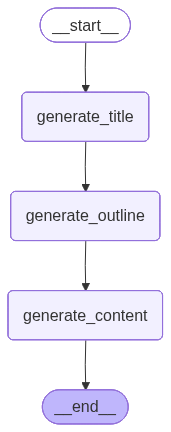

In [13]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [15]:
intial_state = {'topic': 'The Future of AI in Healthcare'}
final_state = workflow.invoke(intial_state)

print(final_state['title'])
print(final_state['outline'])
print(final_state['content'])

Here are a few options:

1. **"Revolutionizing Care: The Rise of AI in Modern Medicine"**
2. **"Healing Through Code: The Future of AI in Healthcare"**
3. **"The AI Advantage: Transforming Healthcare for a Better Tomorrow"**
4. **"Beyond the Doctor's Office: How AI is Transforming Healthcare"**
5. **"Code for Life: The Impact of AI on the Future of Healthcare"**
6. **"The Next Wave: How AI is Revolutionizing Healthcare"**
7. **"Smart Medicine: The Future of AI in Healthcare"**
8. **"From Data to Care: The Power of AI in Modern Healthcare"**
9. **"The Future is Human + Machine: The Rise of AI in Healthcare"**
10. **"Healthcare 2.0: The Role of AI in Shaping the Future of Medicine"**

Feel free to pick the one that resonates with your content the most or use them as inspiration to create your own unique title!
I've chosen the title "**"Revolutionizing Care: The Rise of AI in Modern Medicine"**" as it resonates well with the content I envision for this blog post. Here's a detailed outline